In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/ecommerce_inventory_demand.csv")

In [3]:
df.head()

,date,product_id,product_category,units_sold,unit_price,stock_on_hand,reorder_point,is_promotion,discount_pct,day_of_week,month,supplier_lead_days
0,27-06-2022,P006,Electronics,NaN,10225.02,203,79,0,0.0,0,6,13
1,14-06-2023,P028,Apparel,NaN,1137.33,108,51,0,0.0,2,6,8
2,20-06-2022,P005,Electronics,NaN,8245.58,274,72,0,0.0,0,6,9
3,06-03-2022,P039,Home,NaN,2657.76,179,43,0,0.0,6,3,12
4,01-05-2022,P015,Electronics,NaN,12117.51,205,52,0,0.0,6,5,8


In [4]:
df.isnull().sum()

date                    0
product_id              0
product_category        0
units_sold            249
unit_price              0
stock_on_hand           0
reorder_point           0
is_promotion            0
discount_pct            0
day_of_week             0
month                   0
supplier_lead_days      0
dtype: int64

In [5]:
missing_percent = (df['units_sold'].isnull().sum() / len(df)) * 100
print(f"Missing Percentage: {missing_percent:.2f}%")

Missing Percentage: 4.00%


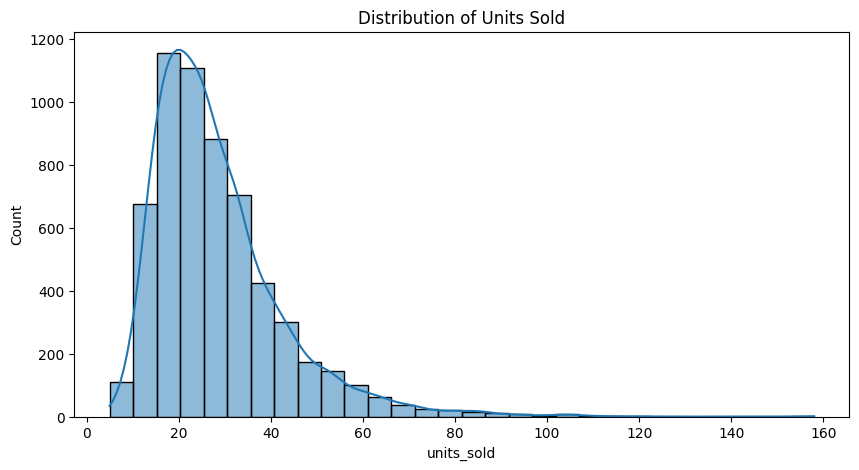

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['units_sold'], bins=30, kde=True)
plt.title("Distribution of Units Sold")
plt.show()

In [7]:
df['product_category'].value_counts()

product_category
Electronics    2968
Apparel        1622
Sports          635
Home            628
Beauty          370
Name: count, dtype: int64

In [8]:
df.groupby('is_promotion')['units_sold'].mean()

is_promotion
0    26.832119
1    53.510145
Name: units_sold, dtype: float64

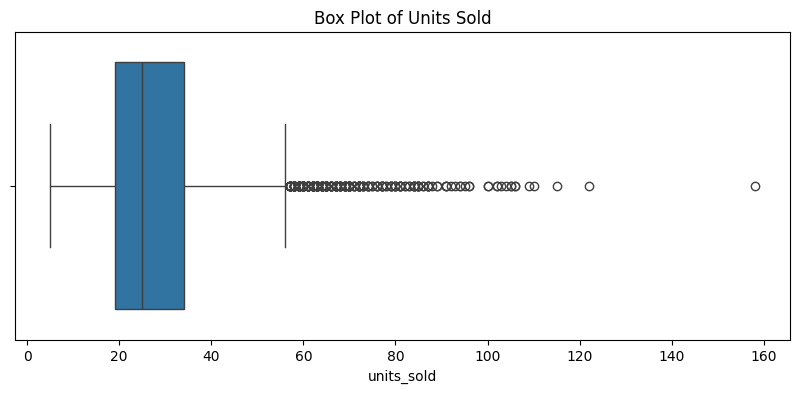

In [9]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['units_sold'])

plt.title("Box Plot of Units Sold")
plt.show()

In [10]:
df['units_sold'].describe()

count    5974.000000
mean       28.372782
std        14.032411
min         5.000000
25%        19.000000
50%        25.000000
75%        34.000000
max       158.000000
Name: units_sold, dtype: float64

In [11]:
df['date'] = pd.to_datetime(df['date'])

print(df['date'].dtype)

datetime64[ns]


C:\Users\hari2\AppData\Local\Temp\ipykernel_10956\1645228349.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [13]:
df.isnull().sum()

date                    0
product_id              0
product_category        0
units_sold            249
unit_price              0
stock_on_hand           0
reorder_point           0
is_promotion            0
discount_pct            0
day_of_week             0
month                   0
supplier_lead_days      0
dtype: int64

In [14]:
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)

datetime64[ns]


In [15]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [16]:
print(df['units_sold'].median())

25.0


In [17]:
df['units_sold'] = df['units_sold'].fillna(
    df['units_sold'].median()
)

In [18]:
df.isnull().sum()

date                  0
product_id            0
product_category      0
units_sold            0
unit_price            0
stock_on_hand         0
reorder_point         0
is_promotion          0
discount_pct          0
day_of_week           0
month                 0
supplier_lead_days    0
dtype: int64

In [19]:
df['is_weekend'] = (
    df['date'].dt.dayofweek >= 5
).astype(int)

In [20]:
df['units_sold'] = df['units_sold'].fillna(
    df['units_sold'].median()
)

df.isnull().sum()

date                  0
product_id            0
product_category      0
units_sold            0
unit_price            0
stock_on_hand         0
reorder_point         0
is_promotion          0
discount_pct          0
day_of_week           0
month                 0
supplier_lead_days    0
is_weekend            0
dtype: int64

In [21]:
df[['date','product_id','units_sold']].head(20)

,date,product_id,units_sold
0,2022-06-27,P006,25.0
1,2023-06-14,P028,25.0
2,2022-06-20,P005,25.0
3,2022-03-06,P039,25.0
4,2022-05-01,P015,25.0
5,2023-05-28,P009,25.0
6,2022-11-10,P034,25.0
7,2023-12-01,P002,25.0
8,2022-10-08,P012,25.0
9,2023-07-30,P046,25.0


In [22]:
df = df.sort_values('date')

df[['date','product_id','units_sold']].head(20)



,date,product_id,units_sold
5271,2022-01-01,P013,46.0
5487,2022-01-01,P002,29.0
2890,2022-01-01,P041,16.0
720,2022-01-01,P028,40.0
2992,2022-01-01,P014,17.0
4763,2022-01-01,P021,36.0
3353,2022-01-01,P046,19.0
4738,2022-01-01,P017,21.0
5274,2022-01-01,P015,14.0
5789,2022-01-01,P049,32.0


In [23]:
df = df.sort_values('date')

df[['date','product_id','units_sold']].head(20)


,date,product_id,units_sold
5271,2022-01-01,P013,46.0
5789,2022-01-01,P049,32.0
5274,2022-01-01,P015,14.0
4738,2022-01-01,P017,21.0
3353,2022-01-01,P046,19.0
4530,2022-01-01,P040,39.0
2992,2022-01-01,P014,17.0
720,2022-01-01,P028,40.0
2890,2022-01-01,P041,16.0
5487,2022-01-01,P002,29.0


In [24]:
print("Unique Products:", df['product_id'].nunique())

Unique Products: 50


In [25]:
df.groupby('product_id').size().head(10)

product_id
P001    146
P002    126
P003    131
P004    114
P005    133
P006    129
P007    123
P008    142
P009    119
P010    136
dtype: int64

In [26]:
print("Unique Products:", df['product_id'].nunique())



Unique Products: 50


In [27]:
df.groupby('product_id').size().head(10)


product_id
P001    146
P002    126
P003    131
P004    114
P005    133
P006    129
P007    123
P008    142
P009    119
P010    136
dtype: int64

In [28]:
df['lag_7'] = (
    df.groupby('product_id')['units_sold']
      .shift(7)
)

df['lag_14'] = (
    df.groupby('product_id')['units_sold']
      .shift(14)
)

In [29]:
df[['product_id',
    'units_sold',
    'lag_7',
    'lag_14']].head(25)


,product_id,units_sold,lag_7,lag_14
5271,P013,46.0,NaN,NaN
5789,P049,32.0,NaN,NaN
5274,P015,14.0,NaN,NaN
4738,P017,21.0,NaN,NaN
3353,P046,19.0,NaN,NaN
4530,P040,39.0,NaN,NaN
2992,P014,17.0,NaN,NaN
720,P028,40.0,NaN,NaN
2890,P041,16.0,NaN,NaN
5487,P002,29.0,NaN,NaN


In [30]:
df['rolling_mean_7'] = (
    df.groupby('product_id')['units_sold']
      .transform(lambda x: x.rolling(7).mean())
)

df['rolling_mean_30'] = (
    df.groupby('product_id')['units_sold']
      .transform(lambda x: x.rolling(30).mean())
)

In [31]:
df[['product_id',
    'units_sold',
    'rolling_mean_7',
    'rolling_mean_30']].head(25)

,product_id,units_sold,rolling_mean_7,rolling_mean_30
5271,P013,46.0,NaN,NaN
5789,P049,32.0,NaN,NaN
5274,P015,14.0,NaN,NaN
4738,P017,21.0,NaN,NaN
3353,P046,19.0,NaN,NaN
4530,P040,39.0,NaN,NaN
2992,P014,17.0,NaN,NaN
720,P028,40.0,NaN,NaN
2890,P041,16.0,NaN,NaN
5487,P002,29.0,NaN,NaN


In [32]:
df[['product_id','units_sold','lag_7','lag_14']].head(25)

,product_id,units_sold,lag_7,lag_14
5271,P013,46.0,NaN,NaN
5789,P049,32.0,NaN,NaN
5274,P015,14.0,NaN,NaN
4738,P017,21.0,NaN,NaN
3353,P046,19.0,NaN,NaN
4530,P040,39.0,NaN,NaN
2992,P014,17.0,NaN,NaN
720,P028,40.0,NaN,NaN
2890,P041,16.0,NaN,NaN
5487,P002,29.0,NaN,NaN


In [33]:
df['rolling_mean_7'] = (
    df.groupby('product_id')['units_sold']
      .transform(lambda x: x.rolling(7).mean())
)

In [34]:
df['rolling_mean_30'] = (
    df.groupby('product_id')['units_sold']
      .transform(lambda x: x.rolling(30).mean())
)

In [35]:
df[['product_id',
    'units_sold',
    'lag_7',
    'lag_14',
    'rolling_mean_7',
    'rolling_mean_30'
]].head(25)

,product_id,units_sold,lag_7,lag_14,rolling_mean_7,rolling_mean_30
5271,P013,46.0,NaN,NaN,NaN,NaN
5789,P049,32.0,NaN,NaN,NaN,NaN
5274,P015,14.0,NaN,NaN,NaN,NaN
4738,P017,21.0,NaN,NaN,NaN,NaN
3353,P046,19.0,NaN,NaN,NaN,NaN
4530,P040,39.0,NaN,NaN,NaN,NaN
2992,P014,17.0,NaN,NaN,NaN,NaN
720,P028,40.0,NaN,NaN,NaN,NaN
2890,P041,16.0,NaN,NaN,NaN,NaN
5487,P002,29.0,NaN,NaN,NaN,NaN


In [36]:
df[['lag_7',
    'lag_14',
    'rolling_mean_7',
    'rolling_mean_30'
]].isnull().sum()

lag_7               350
lag_14              700
rolling_mean_7      300
rolling_mean_30    1450
dtype: int64

In [37]:
df_model = df.dropna().copy()

In [38]:
print(df_model.shape)


(4773, 17)


In [39]:
df_model[['lag_7',
          'lag_14',
          'rolling_mean_7',
          'rolling_mean_30']].isnull().sum()

lag_7              0
lag_14             0
rolling_mean_7     0
rolling_mean_30    0
dtype: int64

In [40]:
print(df_model['product_category'].unique())

['Electronics' 'Sports' 'Apparel' 'Home' 'Beauty']


In [41]:
df[['lag_7',
    'lag_14',
    'rolling_mean_7',
    'rolling_mean_30'
]].isnull().sum()

lag_7               350
lag_14              700
rolling_mean_7      300
rolling_mean_30    1450
dtype: int64

In [42]:
from sklearn.preprocessing import LabelEncoder

category_encoder = LabelEncoder()

df_model['product_category_encoded'] = (
    category_encoder.fit_transform(
        df_model['product_category']
    )
)

In [43]:
df_model[['product_category',
          'product_category_encoded']].head(10)

,product_category,product_category_encoded
4307,Electronics,2
5714,Electronics,2
6090,Electronics,2
356,Electronics,2
196,Sports,4
3629,Electronics,2
4611,Electronics,2
3663,Electronics,2
40,Apparel,0
4909,Electronics,2


In [44]:
print(df_model['product_category'].unique())

['Electronics' 'Sports' 'Apparel' 'Home' 'Beauty']


In [45]:
from sklearn.preprocessing import LabelEncoder

category_encoder = LabelEncoder()

df_model['product_category_encoded'] = (
    category_encoder.fit_transform(
        df_model['product_category']
    )
)

df_model[['product_category',
          'product_category_encoded']].head(10)


,product_category,product_category_encoded
4307,Electronics,2
5714,Electronics,2
6090,Electronics,2
356,Electronics,2
196,Sports,4
3629,Electronics,2
4611,Electronics,2
3663,Electronics,2
40,Apparel,0
4909,Electronics,2


In [47]:
features = [
    'stock_on_hand',
    'reorder_point',
    'is_promotion',
    'discount_pct',
    'supplier_lead_days',
    'is_weekend',
    'lag_7',
    'lag_14',
    'rolling_mean_7',
    'rolling_mean_30',
    'product_category_encoded'
]

X = df_model[features]

y = df_model['units_sold']

In [48]:
print(X.shape)
print(y.shape)

(4773, 11)
(4773,)


In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)



(4773, 11)


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(4773, 11)


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3818, 11)
(955, 11)


In [54]:
import numpy as np

X_train = np.reshape(
    X_train,
    (X_train.shape[0], 1, X_train.shape[1])
)

X_test = np.reshape(
    X_test,
    (X_test.shape[0], 1, X_test.shape[1])
)

print(X_train.shape)
print(X_test.shape)

(3818, 1, 11)
(955, 1, 11)


In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3818, 11)
(955, 11)


In [57]:
import numpy as np

X_train = np.reshape(
    X_train,
    (X_train.shape[0], 1, X_train.shape[1])
)

X_test = np.reshape(
    X_test,
    (X_test.shape[0], 1, X_test.shape[1])
)

print(X_train.shape)
print(X_test.shape)


(3818, 1, 11)
(955, 1, 11)


In [58]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([3818, 1, 11])
torch.Size([3818, 1])


In [59]:
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out


model = LSTMModel(input_size=11)

print(model)

LSTMModel(
  (lstm): LSTM(11, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [60]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [61]:
epochs = 50

for epoch in range(epochs):

    model.train()

    outputs = model(X_train_tensor)

    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )
        

Epoch [5/50], Loss: 1094.3937
Epoch [10/50], Loss: 1091.9198
Epoch [15/50], Loss: 1088.9845
Epoch [20/50], Loss: 1085.2889
Epoch [25/50], Loss: 1080.4404
Epoch [30/50], Loss: 1073.9316
Epoch [35/50], Loss: 1065.1118
Epoch [40/50], Loss: 1053.1830
Epoch [45/50], Loss: 1037.2759
Epoch [50/50], Loss: 1016.6173


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model.eval()

with torch.no_grad():
    y_pred = model(X_test_tensor)

y_pred_np = y_pred.numpy()
y_test_np = y_test_tensor.numpy()

mae = mean_absolute_error(y_test_np, y_pred_np)
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))
r2 = r2_score(y_test_np, y_pred_np)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 28.093544
RMSE: 31.486004
R2 Score: -3.855148265841395


In [63]:
from sklearn.preprocessing import MinMaxScaler

y_scaler = MinMaxScaler()

y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1))

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_scaled,
    test_size=0.2,
    random_state=42
)

In [65]:
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

In [66]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [67]:
model = LSTMModel(input_size=11)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [68]:
epochs = 100

for epoch in range(epochs):
    model.train()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.0544
Epoch [20/100], Loss: 0.0225
Epoch [30/100], Loss: 0.0074
Epoch [40/100], Loss: 0.0089
Epoch [50/100], Loss: 0.0064
Epoch [60/100], Loss: 0.0061
Epoch [70/100], Loss: 0.0053
Epoch [80/100], Loss: 0.0048
Epoch [90/100], Loss: 0.0043
Epoch [100/100], Loss: 0.0039


In [69]:
model.eval()

with torch.no_grad():
    y_pred_scaled = model(X_test_tensor)

y_pred = y_scaler.inverse_transform(y_pred_scaled.numpy())
y_actual = y_scaler.inverse_transform(y_test_tensor.numpy())

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 6.908161
RMSE: 9.071207
R2 Score: 0.5970070074009838


In [72]:
torch.save(
    model.state_dict(),
    "../models/lstm_inventory_model.pth"
)

In [73]:
import os

print(os.path.exists("../models/lstm_inventory_model.pth"))


True


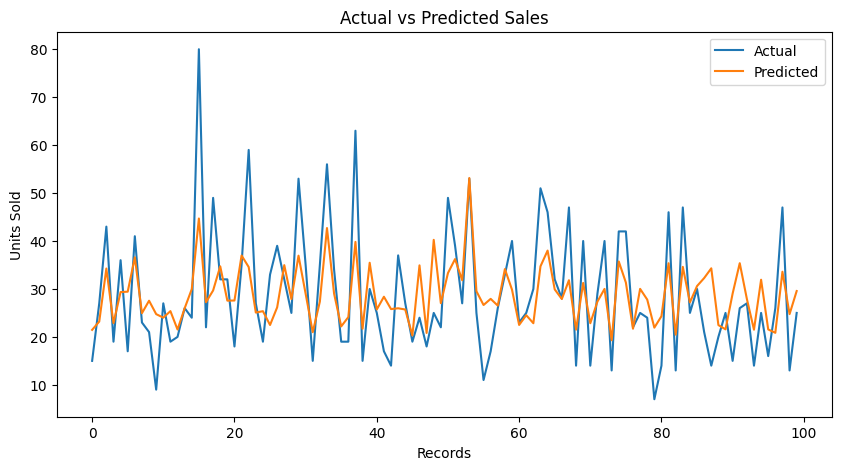

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_actual[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Records")
plt.ylabel("Units Sold")

plt.legend()
plt.show()

In [75]:
import pickle

with open("../models/x_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("../models/y_scaler.pkl", "wb") as f:
    pickle.dump(y_scaler, f)

In [76]:
category_encoder

LabelEncoder()

In [77]:
with open("../models/category_encoder.pkl", "wb") as f:
    pickle.dump(category_encoder, f)

In [78]:
import os

print(os.listdir("../models"))

['category_encoder.pkl', 'lstm_inventory_model.pth', 'x_scaler.pkl', 'y_scaler.pkl']
